<a href="https://colab.research.google.com/github/SenTier1107/DataManagement_2026/blob/main/System_of_Linear_Equations_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📐 System of Linear Equations - Deep Learning Motivation
**2026 Spring | 조상구 교수**

이 노트북은 강의 내용을 정리하고 직접 실습할 수 있도록 구성되었습니다.

---
### 목차
1. 선형 vs 비선형 방정식
2. 연립일차방정식과 기하학적 해석
3. 행렬 형식과 역행렬을 이용한 풀이
4. 선형 독립과 선형 종속
5. 이미지 압축 - Random Projection vs SVD/PCA
6. 퀴즈 풀이

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 한글 폰트 설정 (Colab 환경)
import matplotlib.font_manager as fm
import os

# Colab에서 한글 폰트 설치
!apt-get -qq install fonts-nanum > /dev/null 2>&1
fe = fm.fontManager
fe.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
rcParams['font.family'] = 'NanumGothic'
rcParams['axes.unicode_minus'] = False

print("✅ 환경 설정 완료!")

✅ 환경 설정 완료!


---
## 1. 선형 방정식 vs 비선형 방정식

**선형 방정식 (Linear)**: 변수의 차수가 1이고, 그래프가 직선(또는 평면)인 방정식
- $a + b = 10$
- $2a + 3b = 15$
- $3.4a - 48.99b + 2c = 122.5$

**비선형 방정식 (Non-linear)**: 변수에 제곱, 삼각함수, 지수 등이 포함된 방정식
- $a^2 + b^2 = 10$
- $\sin(a) + b^5 = 15$
- $2^a - 3^b = 0$

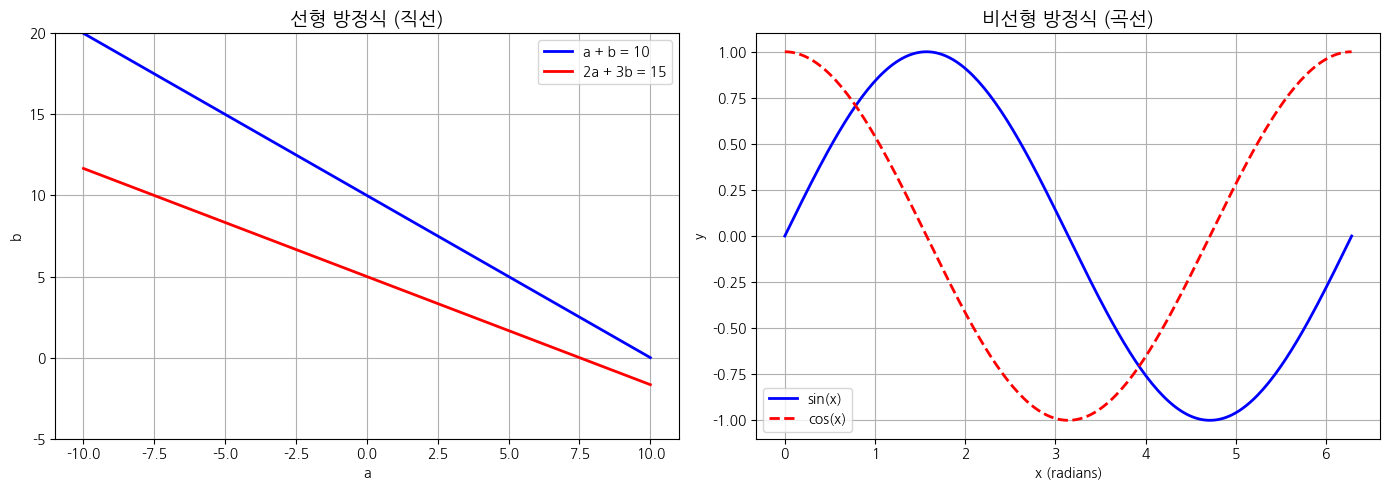

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === 선형 방정식 그래프 ===
a = np.linspace(-10, 10, 200)

# a + b = 10  =>  b = 10 - a
b1 = 10 - a
# 2a + 3b = 15  =>  b = (15 - 2a) / 3
b2 = (15 - 2*a) / 3

axes[0].plot(a, b1, 'b-', linewidth=2, label='a + b = 10')
axes[0].plot(a, b2, 'r-', linewidth=2, label='2a + 3b = 15')
axes[0].set_xlabel('a'); axes[0].set_ylabel('b')
axes[0].set_title('선형 방정식 (직선)', fontsize=14)
axes[0].legend(); axes[0].grid(True); axes[0].set_ylim(-5, 20)

# === 비선형 방정식 그래프 ===
x = np.linspace(0, 2*np.pi, 200)
axes[1].plot(x, np.sin(x), 'b-', linewidth=2, label='sin(x)')
axes[1].plot(x, np.cos(x), 'r--', linewidth=2, label='cos(x)')
axes[1].set_xlabel('x (radians)'); axes[1].set_ylabel('y')
axes[1].set_title('비선형 방정식 (곡선)', fontsize=14)
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## 2. 연립일차방정식 (System of Linear Equations)

두 직선의 관계에 따라 해의 개수가 달라집니다:

| 경우 | 기하학적 의미 | 해의 개수 |
|------|------------|----------|
| 두 직선이 한 점에서 만남 | 교차 | **유일한 해 (unique solution)** |
| 두 직선이 평행 | 만나지 않음 | **해 없음 (no solution)** |
| 두 직선이 겹침 | 동일 | **무한히 많은 해 (infinite solutions)** |

### 예제: $3a + 2b = 8$, $2a - b = 3$

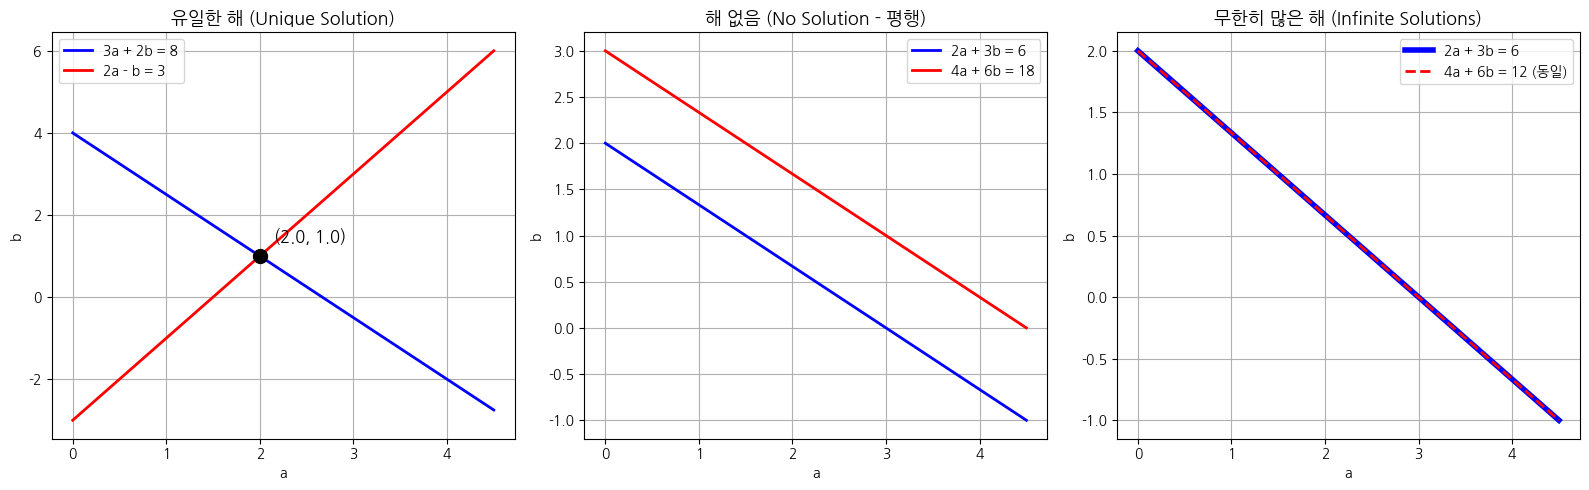

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

a_vals = np.linspace(0, 4.5, 200)

# Case 1: 유일한 해 (교차)
b_eq1 = (8 - 3*a_vals) / 2   # 3a + 2b = 8
b_eq2 = 2*a_vals - 3          # 2a - b = 3  =>  b = 2a - 3

axes[0].plot(a_vals, b_eq1, 'b-', linewidth=2, label='3a + 2b = 8')
axes[0].plot(a_vals, b_eq2, 'r-', linewidth=2, label='2a - b = 3')
axes[0].plot(2, 1, 'ko', markersize=10, zorder=5)
axes[0].annotate('(2.0, 1.0)', (2, 1), textcoords='offset points',
                 xytext=(10, 10), fontsize=12, fontweight='bold')
axes[0].set_title('유일한 해 (Unique Solution)', fontsize=13)
axes[0].legend(); axes[0].grid(True)
axes[0].set_xlabel('a'); axes[0].set_ylabel('b')

# Case 2: 해 없음 (평행)
b_p1 = (6 - 2*a_vals) / 3
b_p2 = (12 - 4*a_vals) / 6 + 1  # 평행 이동
axes[1].plot(a_vals, b_p1, 'b-', linewidth=2, label='2a + 3b = 6')
axes[1].plot(a_vals, b_p2, 'r-', linewidth=2, label='4a + 6b = 18')
axes[1].set_title('해 없음 (No Solution - 평행)', fontsize=13)
axes[1].legend(); axes[1].grid(True)
axes[1].set_xlabel('a'); axes[1].set_ylabel('b')

# Case 3: 무한히 많은 해 (겹침)
b_i1 = (6 - 2*a_vals) / 3
b_i2 = (12 - 4*a_vals) / 6  # 같은 직선
axes[2].plot(a_vals, b_i1, 'b-', linewidth=4, label='2a + 3b = 6')
axes[2].plot(a_vals, b_i2, 'r--', linewidth=2, label='4a + 6b = 12 (동일)')
axes[2].set_title('무한히 많은 해 (Infinite Solutions)', fontsize=13)
axes[2].legend(); axes[2].grid(True)
axes[2].set_xlabel('a'); axes[2].set_ylabel('b')

plt.tight_layout()
plt.show()

---
## 3. 행렬 형식과 역행렬을 이용한 풀이

연립방정식을 행렬로 표현:

$$Ax = B$$

$$\begin{bmatrix} 3 & 2 \\ 2 & -1 \end{bmatrix} \begin{bmatrix} a \\ b \end{bmatrix} = \begin{bmatrix} 8 \\ 3 \end{bmatrix}$$

풀이 과정:
1. $Ax = B$
2. $A^{-1}(Ax) = A^{-1}B$
3. $Ix = A^{-1}B$ (단, $I$는 단위행렬)
4. $x = A^{-1}B$

### 2×2 역행렬 공식

$$A = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \Rightarrow A^{-1} = \frac{1}{ad - bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

여기서 $\det(A) = ad - bc \neq 0$ 이어야 역행렬이 존재합니다.

In [4]:
# === 강의 예제 그대로 실습 ===

# 1. 행렬 설정
A = np.array([[3, 2], [2, -1]])
B = np.array([[8], [3]])

print("="*50)
print("연립방정식: 3a + 2b = 8, 2a - b = 3")
print("="*50)

# 2. 행렬식(Determinant) 계산
det_A = np.linalg.det(A)
print(f"\n1. 행렬식 det(A) = {det_A:.1f}")

if det_A != 0:
    # 3. 역행렬 계산
    print(f"\n2. 행렬 A:\n{A}")

    A_inv = np.linalg.inv(A)
    print(f"\n3. 역행렬 A⁻¹:\n{A_inv}")

    # 검증: A⁻¹ × A = I
    print(f"\n4. 검증 A⁻¹ × A (단위행렬이 되어야 함):\n{np.round(A_inv @ A, 10)}")

    # 4. 해 계산 (x = A⁻¹ @ B)
    X = A_inv @ B
    print(f"\n5. 최종 해: a = {X[0][0]:.1f}, b = {X[1][0]:.1f}")
else:
    print("행렬식이 0이므로 역행렬이 존재하지 않습니다.")

연립방정식: 3a + 2b = 8, 2a - b = 3

1. 행렬식 det(A) = -7.0

2. 행렬 A:
[[ 3  2]
 [ 2 -1]]

3. 역행렬 A⁻¹:
[[ 0.14285714  0.28571429]
 [ 0.28571429 -0.42857143]]

4. 검증 A⁻¹ × A (단위행렬이 되어야 함):
[[ 1.  0.]
 [-0.  1.]]

5. 최종 해: a = 2.0, b = 1.0


In [5]:
# === np.linalg.solve 로 더 간단하게 풀기 ===
X_solve = np.linalg.solve(A, B)
print(f"np.linalg.solve 결과: a = {X_solve[0][0]:.1f}, b = {X_solve[1][0]:.1f}")

# 검증: A @ X = B ?
print(f"\n검증 A @ X = {(A @ X_solve).flatten()} (= B = {B.flatten()})")

np.linalg.solve 결과: a = 2.0, b = 1.0

검증 A @ X = [8. 3.] (= B = [8 3])


### 💡 1차 방정식과의 비교 (스칼라 vs 행렬)

| 스칼라 | 행렬 |
|--------|------|
| $4x = 16$ | $Ax = B$ |
| 양변에 $\frac{1}{4}$ 곱하기 | 양변에 $A^{-1}$ 곱하기 |
| $x = 4$ | $x = A^{-1}B$ |

---
## 4. 선형 독립 (Linear Independence) vs 선형 종속 (Linear Dependence)

**선형 독립**: 어떤 벡터도 다른 벡터들의 선형 결합으로 표현할 수 **없는** 경우
- $\det(A) \neq 0$ → 역행렬 존재 (Non-singular)

**선형 종속**: 적어도 하나의 벡터가 다른 벡터들의 선형 결합으로 표현 **가능**한 경우
- $\det(A) = 0$ → 역행렬 없음 (Singular)

In [6]:
# === 강의 Quiz (슬라이드 12-13): 행벡터의 선형 독립/종속 판별 ===

matrices = {
    "행렬 1": np.array([[1, 0, 1],
                        [0, 1, 0],
                        [3, 2, 3]]),

    "행렬 2": np.array([[1, 1, 1],
                        [1, 1, 2],
                        [0, 0, -1]]),

    "행렬 3": np.array([[1, 1, 1],
                        [0, 2, 2],
                        [0, 0, 3]]),

    "행렬 4": np.array([[1, 2, 5],
                        [0, 3, -2],
                        [2, 4, 10]])
}

print("=" * 60)
print("행벡터의 선형 독립/종속 판별 (행렬식 이용)")
print("=" * 60)

for name, M in matrices.items():
    det = np.linalg.det(M)
    rank = np.linalg.matrix_rank(M)
    status = "독립 (Non-singular)" if abs(det) > 1e-10 else "종속 (Singular)"
    print(f"\n{name}:")
    print(M)
    print(f"  det = {det:.4f}, rank = {rank} → {status}")

행벡터의 선형 독립/종속 판별 (행렬식 이용)

행렬 1:
[[1 0 1]
 [0 1 0]
 [3 2 3]]
  det = 0.0000, rank = 2 → 종속 (Singular)

행렬 2:
[[ 1  1  1]
 [ 1  1  2]
 [ 0  0 -1]]
  det = 0.0000, rank = 2 → 종속 (Singular)

행렬 3:
[[1 1 1]
 [0 2 2]
 [0 0 3]]
  det = 6.0000, rank = 3 → 독립 (Non-singular)

행렬 4:
[[ 1  2  5]
 [ 0  3 -2]
 [ 2  4 10]]
  det = 0.0000, rank = 2 → 종속 (Singular)


In [7]:
# === 행 사이의 관계 확인 ===

print("\n" + "=" * 60)
print("행 사이의 관계 (강의 슬라이드 13)")
print("=" * 60)

M1 = matrices["행렬 1"]
print(f"\n행렬 1: 3*Row1 + 2*Row2 = {3*M1[0] + 2*M1[1]}  vs  Row3 = {M1[2]}")
print("  → 3*Row1 + 2*Row2 = Row3 이므로 종속!")

M2 = matrices["행렬 2"]
print(f"\n행렬 2: Row1 - Row2 = {M2[0] - M2[1]}  vs  Row3 = {M2[2]}")
print("  → Row1 - Row2 = Row3 이므로 종속!")

print(f"\n행렬 3: 행 사이에 선형 관계 없음 → 독립!")

M4 = matrices["행렬 4"]
print(f"\n행렬 4: 2*Row1 = {2*M4[0]}  vs  Row3 = {M4[2]}")
print("  → 2*Row1 = Row3 이므로 종속!")


행 사이의 관계 (강의 슬라이드 13)

행렬 1: 3*Row1 + 2*Row2 = [3 2 3]  vs  Row3 = [3 2 3]
  → 3*Row1 + 2*Row2 = Row3 이므로 종속!

행렬 2: Row1 - Row2 = [ 0  0 -1]  vs  Row3 = [ 0  0 -1]
  → Row1 - Row2 = Row3 이므로 종속!

행렬 3: 행 사이에 선형 관계 없음 → 독립!

행렬 4: 2*Row1 = [ 2  4 10]  vs  Row3 = [ 2  4 10]
  → 2*Row1 = Row3 이므로 종속!


### 🧠 Quiz (슬라이드 14): 열벡터의 선형 독립/종속

In [8]:
# 슬라이드 14 - 왼쪽 문제
quiz_left = {
    "A": np.array([[2, 4, 8], [1, 2, 4], [3, 6, 12]]),
    "B": np.array([[1, 2, 3], [1, 2, 3], [1, 2, 3]]),
    "C": np.array([[1, 2, 3], [0, 4, 5], [0, 0, 6]]),
    "D": np.array([[1, 0, 1], [0, 1, 1], [0, 0, 0]])
}

print("=" * 50)
print("열벡터 선형 독립/종속 판별 (왼쪽 문제)")
print("=" * 50)

for label, M in quiz_left.items():
    det = np.linalg.det(M)
    rank = np.linalg.matrix_rank(M)
    status = "독립" if abs(det) > 1e-10 else "종속"
    print(f"\n{label}. det = {det:.4f}, rank = {rank} → 열벡터 {status}")
    print(M)

열벡터 선형 독립/종속 판별 (왼쪽 문제)

A. det = 0.0000, rank = 1 → 열벡터 종속
[[ 2  4  8]
 [ 1  2  4]
 [ 3  6 12]]

B. det = 0.0000, rank = 1 → 열벡터 종속
[[1 2 3]
 [1 2 3]
 [1 2 3]]

C. det = 24.0000, rank = 3 → 열벡터 독립
[[1 2 3]
 [0 4 5]
 [0 0 6]]

D. det = 0.0000, rank = 2 → 열벡터 종속
[[1 0 1]
 [0 1 1]
 [0 0 0]]


In [9]:
# 슬라이드 14 - 오른쪽 문제
quiz_right = {
    "A": np.array([[1, 2, 3], [2, 4, 6], [3, 6, 9]]),
    "B": np.array([[1, 1, 2], [1, 0, 1], [0, 1, 1]]),
    "C": np.array([[1, 0, 0], [0, 2, 0], [0, 0, 3]]),
    "D": np.array([[1, 2, 3], [0, 0, 0], [4, 5, 6]])
}

print("=" * 50)
print("열벡터 선형 독립/종속 판별 (오른쪽 문제)")
print("=" * 50)

for label, M in quiz_right.items():
    det = np.linalg.det(M)
    rank = np.linalg.matrix_rank(M)
    status = "독립" if abs(det) > 1e-10 else "종속"
    print(f"\n{label}. det = {det:.4f}, rank = {rank} → 열벡터 {status}")
    print(M)

열벡터 선형 독립/종속 판별 (오른쪽 문제)

A. det = 0.0000, rank = 1 → 열벡터 종속
[[1 2 3]
 [2 4 6]
 [3 6 9]]

B. det = 0.0000, rank = 2 → 열벡터 종속
[[1 1 2]
 [1 0 1]
 [0 1 1]]

C. det = 6.0000, rank = 3 → 열벡터 독립
[[1 0 0]
 [0 2 0]
 [0 0 3]]

D. det = 0.0000, rank = 2 → 열벡터 종속
[[1 2 3]
 [0 0 0]
 [4 5 6]]


In [10]:
# === 슬라이드 15: Quiz 3 ===
# 열벡터가 선형 독립이 되기 위해 x가 가질 수 없는 값은?

print("=" * 50)
print("Quiz 3: x가 가질 수 없는 값 찾기")
print("=" * 50)
print("\n행렬: [[1, 0, 2], [0, 1, 3], [0, 0, x]]")
print("\ndet = 1 * 1 * x = x")
print("선형 독립이 되려면 det ≠ 0, 즉 x ≠ 0")
print("\n정답: B. x = 0 (이 값이면 열벡터가 종속이 됨)")

# 검증
for x_val in [1, 0, 2, -1]:
    M = np.array([[1, 0, 2], [0, 1, 3], [0, 0, x_val]])
    det = np.linalg.det(M)
    print(f"  x = {x_val:2d} → det = {det:.1f} → {'종속 ❌' if abs(det) < 1e-10 else '독립 ✅'}")

Quiz 3: x가 가질 수 없는 값 찾기

행렬: [[1, 0, 2], [0, 1, 3], [0, 0, x]]

det = 1 * 1 * x = x
선형 독립이 되려면 det ≠ 0, 즉 x ≠ 0

정답: B. x = 0 (이 값이면 열벡터가 종속이 됨)
  x =  1 → det = 1.0 → 독립 ✅
  x =  0 → det = 0.0 → 종속 ❌
  x =  2 → det = 2.0 → 독립 ✅
  x = -1 → det = -1.0 → 독립 ✅


In [11]:
# === 슬라이드 15: Quiz 4 ===
# Rank가 3인 행렬 (즉, 열이 모두 독립인 행렬)은?

print("=" * 50)
print("Quiz 4: Rank가 3인 행렬 찾기")
print("=" * 50)

quiz4 = {
    "A": np.array([[1, 0, 0], [2, 0, 0], [3, 0, 0]]),
    "B": np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]),
    "C": np.array([[1, 2, 3], [4, 5, 6], [5, 7, 9]]),
    "D": np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]])
}

for label, M in quiz4.items():
    rank = np.linalg.matrix_rank(M)
    det = np.linalg.det(M)
    marker = " ✅ 정답!" if rank == 3 else ""
    print(f"\n{label}. rank = {rank}, det = {det:.4f}{marker}")
    print(M)

Quiz 4: Rank가 3인 행렬 찾기

A. rank = 1, det = 0.0000
[[1 0 0]
 [2 0 0]
 [3 0 0]]

B. rank = 1, det = 0.0000
[[1 1 1]
 [1 1 1]
 [1 1 1]]

C. rank = 2, det = 0.0000
[[1 2 3]
 [4 5 6]
 [5 7 9]]

D. rank = 3, det = -1.0000 ✅ 정답!
[[0 0 1]
 [0 1 0]
 [1 0 0]]


---
## 5. 이미지 압축 - Rank Reduction

### 5.1 Random Projection으로 Rank 줄이기
무작위로 feature를 선택하면 정보 손실이 큼

### 5.2 SVD (Singular Value Decomposition)로 Rank 줄이기
가장 중요한 특이값부터 선택하므로 적은 rank로도 원본에 가까운 복원 가능

$$A = U \Sigma V^T$$

rank-$k$ 근사: $A_k = U_k \Sigma_k V_k^T$

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
이미지 크기: (256, 256)
원본 Rank: 64


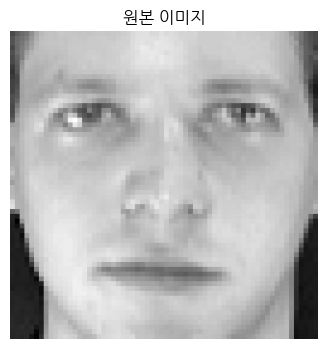

In [12]:
from PIL import Image
import requests
from io import BytesIO

# 샘플 이미지 로드 (Colab에서 바로 사용 가능한 이미지)
# 임의의 그레이스케일 이미지 생성 (사람 얼굴 대신 패턴 이미지)
np.random.seed(42)

# 또는 sklearn의 샘플 얼굴 데이터 사용
try:
    from sklearn.datasets import fetch_olivetti_faces
    faces = fetch_olivetti_faces()
    img = faces.images[0]  # 64x64 얼굴 이미지
    # 더 큰 이미지로 리사이즈
    img_large = np.kron(img, np.ones((4, 4)))  # 256x256으로 확대
    print(f"이미지 크기: {img_large.shape}")
    print(f"원본 Rank: {np.linalg.matrix_rank(img_large)}")

    plt.figure(figsize=(4, 4))
    plt.imshow(img_large, cmap='gray')
    plt.title('원본 이미지')
    plt.axis('off')
    plt.show()
except:
    # 패턴 이미지로 대체
    x = np.linspace(-3, 3, 256)
    y = np.linspace(-3, 3, 256)
    X, Y = np.meshgrid(x, y)
    img_large = np.exp(-(X**2 + Y**2)/2) + 0.3*np.sin(5*X)*np.cos(5*Y)
    print(f"이미지 크기: {img_large.shape}")

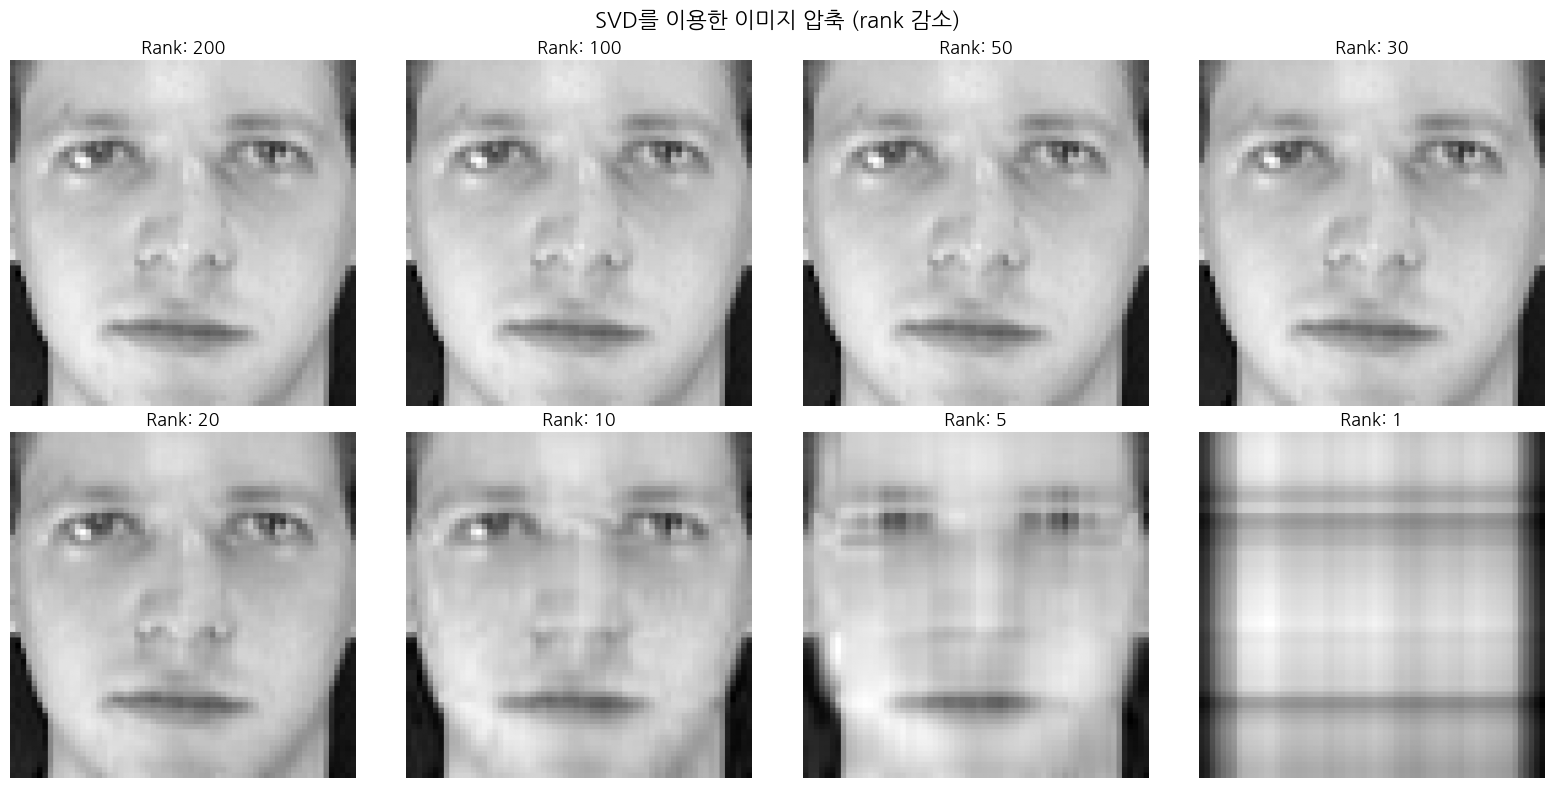

In [13]:
# === Random Projection vs SVD 비교 ===

def random_projection(image, rank):
    """무작위 열을 선택하여 rank를 줄임"""
    m, n = image.shape
    if rank >= n:
        return image.copy()
    indices = np.random.choice(n, rank, replace=False)
    indices.sort()
    reduced = np.zeros_like(image)
    reduced[:, indices] = image[:, indices]
    return reduced

def svd_compression(image, rank):
    """SVD를 사용하여 rank-k 근사"""
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    return U[:, :rank] @ np.diag(S[:rank]) @ Vt[:rank, :]

ranks = [200, 100, 50, 30, 20, 10, 5, 1]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('SVD를 이용한 이미지 압축 (rank 감소)', fontsize=16)

for idx, rank in enumerate(ranks):
    row, col = idx // 4, idx % 4
    compressed = svd_compression(img_large, rank)
    axes[row, col].imshow(compressed, cmap='gray')
    axes[row, col].set_title(f'Rank: {rank}', fontsize=13)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

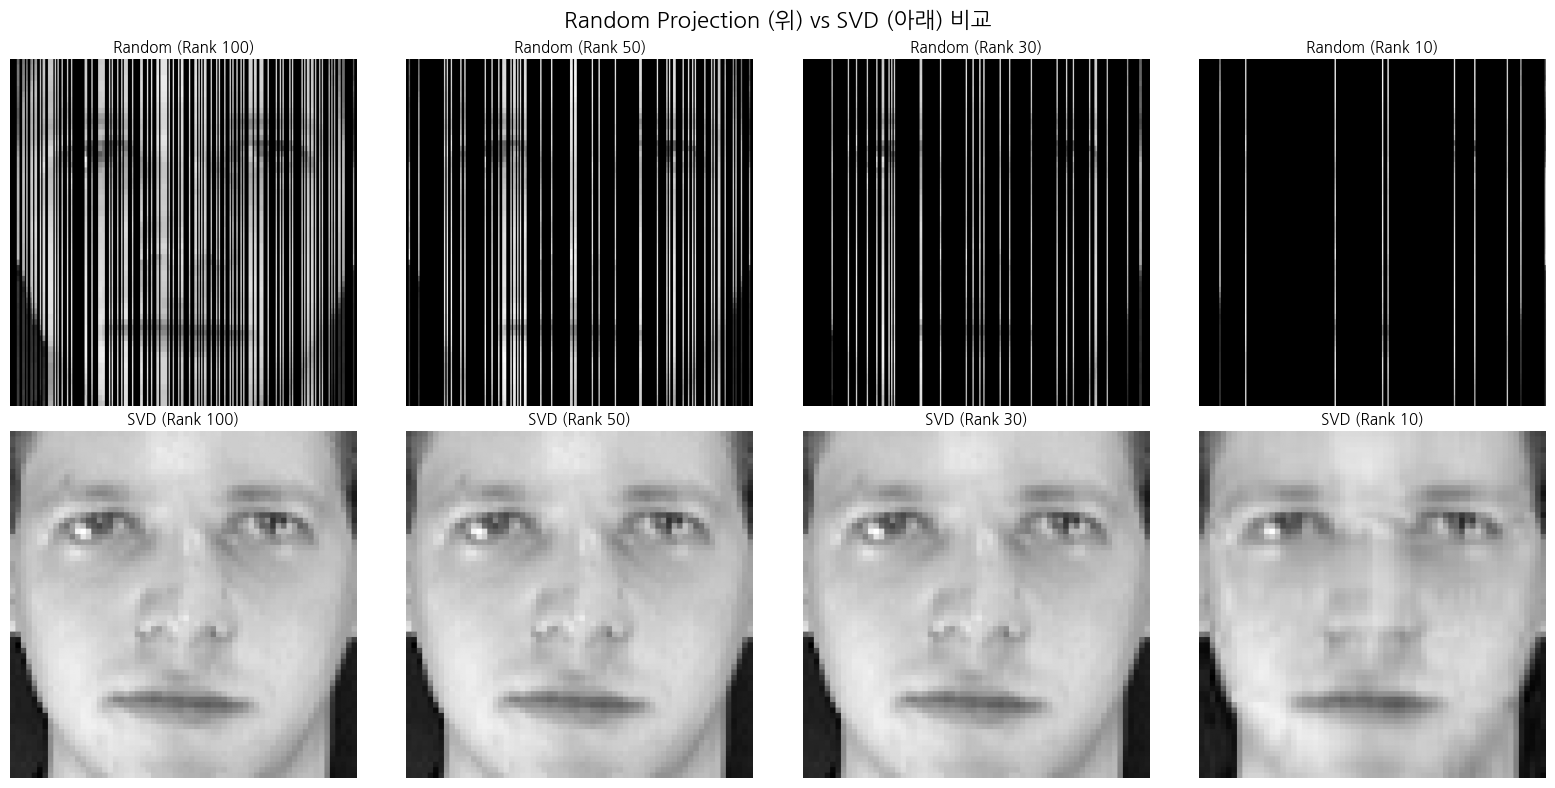

💡 SVD는 가장 중요한 특이값부터 선택하기 때문에,
   낮은 rank에서도 원본의 주요 특징(얼굴 형태 등)을 잘 보존합니다.
   반면 Random Projection은 무작위 선택이므로 정보 손실이 훨씬 큽니다.


In [14]:
# === Random Projection과 SVD 비교 ===

compare_ranks = [100, 50, 30, 10]

fig, axes = plt.subplots(2, len(compare_ranks), figsize=(16, 8))
fig.suptitle('Random Projection (위) vs SVD (아래) 비교', fontsize=16)

np.random.seed(42)
for idx, rank in enumerate(compare_ranks):
    # Random Projection
    rp = random_projection(img_large, rank)
    axes[0, idx].imshow(rp, cmap='gray')
    axes[0, idx].set_title(f'Random (Rank {rank})', fontsize=11)
    axes[0, idx].axis('off')

    # SVD
    sv = svd_compression(img_large, rank)
    axes[1, idx].imshow(sv, cmap='gray')
    axes[1, idx].set_title(f'SVD (Rank {rank})', fontsize=11)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print("💡 SVD는 가장 중요한 특이값부터 선택하기 때문에,")
print("   낮은 rank에서도 원본의 주요 특징(얼굴 형태 등)을 잘 보존합니다.")
print("   반면 Random Projection은 무작위 선택이므로 정보 손실이 훨씬 큽니다.")

90% 정보 보존에 필요한 rank: 1
95% 정보 보존에 필요한 rank: 1
원본 rank: 256


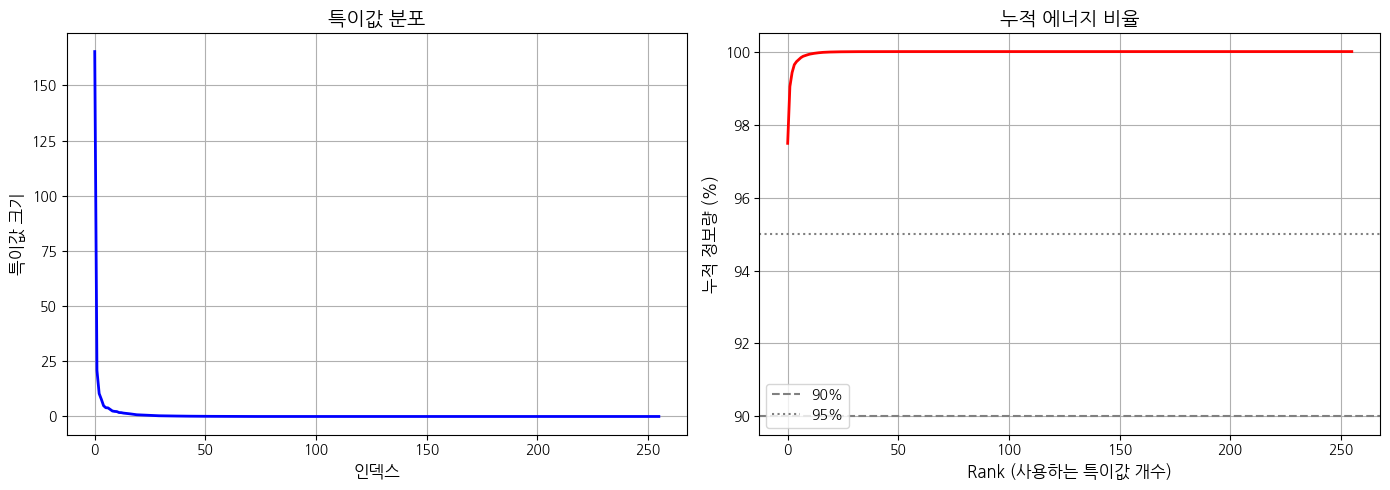

In [15]:
# === 특이값(Singular Values) 분포 확인 ===

U, S, Vt = np.linalg.svd(img_large, full_matrices=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 특이값 크기
axes[0].plot(S, 'b-', linewidth=2)
axes[0].set_xlabel('인덱스', fontsize=12)
axes[0].set_ylabel('특이값 크기', fontsize=12)
axes[0].set_title('특이값 분포', fontsize=14)
axes[0].grid(True)

# 누적 설명 비율
cumulative = np.cumsum(S**2) / np.sum(S**2) * 100
axes[1].plot(cumulative, 'r-', linewidth=2)
axes[1].axhline(y=90, color='gray', linestyle='--', label='90%')
axes[1].axhline(y=95, color='gray', linestyle=':', label='95%')
axes[1].set_xlabel('Rank (사용하는 특이값 개수)', fontsize=12)
axes[1].set_ylabel('누적 정보량 (%)', fontsize=12)
axes[1].set_title('누적 에너지 비율', fontsize=14)
axes[1].legend(); axes[1].grid(True)

# 90%, 95% 달성 rank 찾기
rank_90 = np.argmax(cumulative >= 90) + 1
rank_95 = np.argmax(cumulative >= 95) + 1
print(f"90% 정보 보존에 필요한 rank: {rank_90}")
print(f"95% 정보 보존에 필요한 rank: {rank_95}")
print(f"원본 rank: {len(S)}")

plt.tight_layout()
plt.show()

---
## 6. 추가 실습: 직접 해보기

아래 셀에서 직접 연립방정식을 만들어 풀어보세요!

In [16]:
# === 직접 실습: 3x3 연립방정식 풀기 ===
# 예: x + 2y + 3z = 14
#     2x + 5y + 6z = 30
#     3x + y + z = 10

A3 = np.array([[1, 2, 3],
               [2, 5, 6],
               [3, 1, 1]])

B3 = np.array([[14], [30], [10]])

print("연립방정식:")
print("  x + 2y + 3z = 14")
print("  2x + 5y + 6z = 30")
print("  3x + y +  z = 10")

det_A3 = np.linalg.det(A3)
print(f"\ndet(A) = {det_A3:.4f}")

if abs(det_A3) > 1e-10:
    X3 = np.linalg.solve(A3, B3)
    print(f"\n해: x = {X3[0][0]:.2f}, y = {X3[1][0]:.2f}, z = {X3[2][0]:.2f}")

    # 검증
    print(f"\n검증 A @ X = {(A3 @ X3).flatten()}")
    print(f"     B     = {B3.flatten()}")
else:
    print("\n해가 유일하지 않습니다 (det = 0)")

연립방정식:
  x + 2y + 3z = 14
  2x + 5y + 6z = 30
  3x + y +  z = 10

det(A) = -8.0000

해: x = 1.75, y = 2.00, z = 2.75

검증 A @ X = [14. 30. 10.]
     B     = [14 30 10]


---
## 📝 핵심 정리

| 개념 | 설명 | Python |
|------|------|--------|
| 행렬식 | $\det(A) \neq 0$ → 역행렬 존재 | `np.linalg.det(A)` |
| 역행렬 | $A^{-1}A = I$ | `np.linalg.inv(A)` |
| 연립방정식 풀기 | $x = A^{-1}B$ | `np.linalg.solve(A, B)` |
| Rank | 독립인 행/열의 개수 | `np.linalg.matrix_rank(A)` |
| SVD | $A = U\Sigma V^T$ | `np.linalg.svd(A)` |

**딥러닝과의 연결**:
- 신경망의 각 층은 행렬 연산 ($y = Wx + b$)
- 가중치 행렬의 rank → 모델의 표현력
- SVD/PCA → 차원 축소, 데이터 압축에 활용
- 선형 독립 → feature의 다양성 (중복 없는 정보)